# Pattern Graph

Yun Gui

## Overview

Reference:
[1] AVITAN L, PUJIC Z, MÖLTER J, 等, 2017. Spontaneous Activity in the Zebrafish Tectum Reorganizes over Development and Is Influenced by Visual Experience: 卷 27[Z/OL]. Current Biology: 2407-2419.e4. [https://www.semanticscholar.org/paper/97a5bc942ae61369182f4b23baa4a1e0cd83e3fe](https://www.semanticscholar.org/paper/97a5bc942ae61369182f4b23baa4a1e0cd83e3fe). DOI:[10.1016/j.cub.2017.06.056](https://doi.org/10.1016/j.cub.2017.06.056).

In [1]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data

base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1028", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
data_path = base_dir + data_paths[7] # 'M77_1031'
print(f"Processing data from: {data_path}")

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M79_1128


## Data Loading and Preprocessing

load spike data



In [2]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
        extract_rr=1
    )


原始神经数据形状: (8402, 27033)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 262 个 RR 神经元
  - 类别 2 贡献了 253 个 RR 神经元
  - 类别 3 贡献了 188 个 RR 神经元
三类并集后共筛选出 365 个唯一 RR 神经元


In [3]:
segments_spi.shape, labels_spi.shape, neuron_pos_spi.shape

((180, 365, 50), (180,), (2, 365))

## Reduce dimensionality with UMAP

首先将X转化成长度为N的向量，这里先没有做0-1处理，我觉得我不需要看哪些神经元一起发放【暂时】，这里通过UMAP进行一个简单的降维并查看松散度；

2026-03-05 20:05:36.549403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


平衡后数据形状: (165, 365)
最终数据形状 (含静息态): (220, 365)


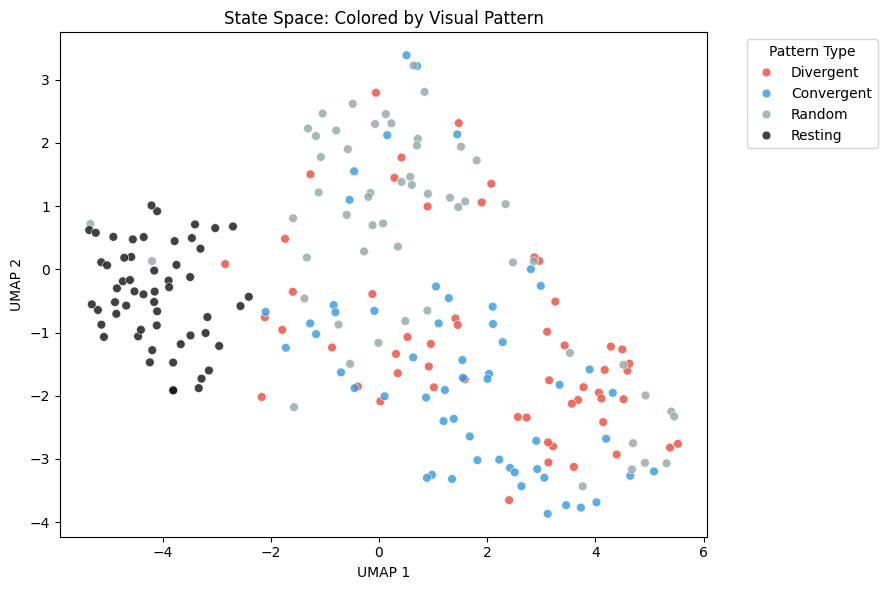

In [4]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)

print(f"平衡后数据形状: {X_trial_averaged_balanced.shape}") # 应为 (min_count * 3, 神经元数)

# 随机再选择同样数量的trial，提取前面的静息态数据进行对比
trial_indices = np.arange(segments_spi.shape[0])
np.random.shuffle(trial_indices)
selected_indices = trial_indices[:min_count]
X_rest_balanced = np.mean(segments_spi[selected_indices, :, 5:10], axis=2)

X_trial_averaged_balanced = np.vstack([X_trial_averaged_balanced, X_rest_balanced])
labels_balanced = np.concatenate([labels_balanced, np.zeros(min_count)]) # 0
print(f"最终数据形状 (含静息态): {X_trial_averaged_balanced.shape}") # 应为 (min_count * 4, 神经元数)
# 2. 对 Trial 级别的数据进行降维 (UMAP)
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3) 
embedding = reducer.fit_transform(X_trial_averaged_balanced)

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
# 这里的颜色方案：Divergent(红), Convergent(蓝), Random(灰/绿) resting(黑)
palette = {1: "#e74c3c", 2: "#3498db", 3: "#95a5a6", 0: "#111111"}

def plot_pattern_space(embedding, labels, title):
    plt.figure(figsize=(9, 6))
    
    # 转换为语义标签方便绘图
    semantic_labels = [label_names[l] for l in labels]
    
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=semantic_labels,
        palette=['#e74c3c', '#3498db', '#95a5a6', '#111111'], # 对应顺序
        s=40, alpha=0.8, edgecolor='w'
    )
    
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Pattern Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 绘图
plot_pattern_space(embedding, labels_balanced, "State Space: Colored by Visual Pattern")

In [5]:
labels_balanced

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [6]:
# embedding 是 UMAP 降维后的 (n_trials, 2) 矩阵
for label in np.unique(labels_balanced):
    mask = (labels_balanced == label)
    cluster_points = embedding[mask]
    
    # 计算质心距离的标准差（衡量簇的半径/松散程度）
    centroid = np.mean(cluster_points, axis=0)
    dist_to_centroid = np.linalg.norm(cluster_points - centroid, axis=1)
    cluster_std = np.std(dist_to_centroid)
    
    print(f"刺激 {label_names[label]} 在状态空间中的松散度 (STD): {cluster_std:.4f}")


刺激 Resting 在状态空间中的松散度 (STD): 0.4391
刺激 Divergent 在状态空间中的松散度 (STD): 1.0286
刺激 Convergent 在状态空间中的松散度 (STD): 1.1548
刺激 Random 在状态空间中的松散度 (STD): 1.5090


In [7]:
def calculate_participation_ratio(data):
    """
    data: (n_samples, n_features) - 这里的 feature 可以是神经元，也可以是 pattern 的特征
    """
    # 1. 中心化数据
    data_centered = data - np.mean(data, axis=0)
    # 2. 计算协方差矩阵
    cov_matrix = np.cov(data_centered, rowvar=False)
    # 3. 获取特征值
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    eigenvalues = eigenvalues[eigenvalues > 1e-10] # 去除数值噪声
    
    # 4. 计算 PR
    pr = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
    return pr

# 如果想用更专业的非线性维度估计（推荐）：
# pip install scikit-dimension
import skdim

def calculate_intrinsic_dimension(data):
    # 使用 Two-NN 估算本征维度
    twonn = skdim.id.TwoNN().fit(data)
    return twonn.dimension_

for label in np.unique(labels_balanced):
    mask = (labels_balanced == label)
    cluster_data = X_trial_averaged_balanced[mask]
    
    pr = calculate_participation_ratio(cluster_data)
    id_dim = calculate_intrinsic_dimension(cluster_data)
    
    print(f"刺激 {label_names[label]} 的参与度维数 (PR): {pr:.4f}, 本征维数 (ID): {id_dim:.4f}")


刺激 Resting 的参与度维数 (PR): 8.4314, 本征维数 (ID): 34.4750
刺激 Divergent 的参与度维数 (PR): 15.7740, 本征维数 (ID): 14.0030
刺激 Convergent 的参与度维数 (PR): 13.6430, 本征维数 (ID): 11.7420
刺激 Random 的参与度维数 (PR): 14.0450, 本征维数 (ID): 20.2896


##  Spectrum cluster

首先先用谱聚类对向量进行聚类，这个过程本质是无监督的，然后计算其模块和真实标签的重合程度

In [8]:
from sklearn.cluster import SpectralClustering

# 1. 准备数据 X (n_trials, n_neurons)
# 2. 定义谱聚类模型
# n_clusters: 聚类数量
# affinity: 'cosine' 或 'nearest_neighbors'（文献中常用 nearest_neighbors 构建图）



spectral_model = SpectralClustering(
    n_clusters=5, 
    affinity='nearest_neighbors', 
    n_neighbors=10, 
    assign_labels='kmeans', 
    random_state=42
)

# 3. 进行聚类
cluster_labels = spectral_model.fit_predict(X_trial_averaged_balanced)


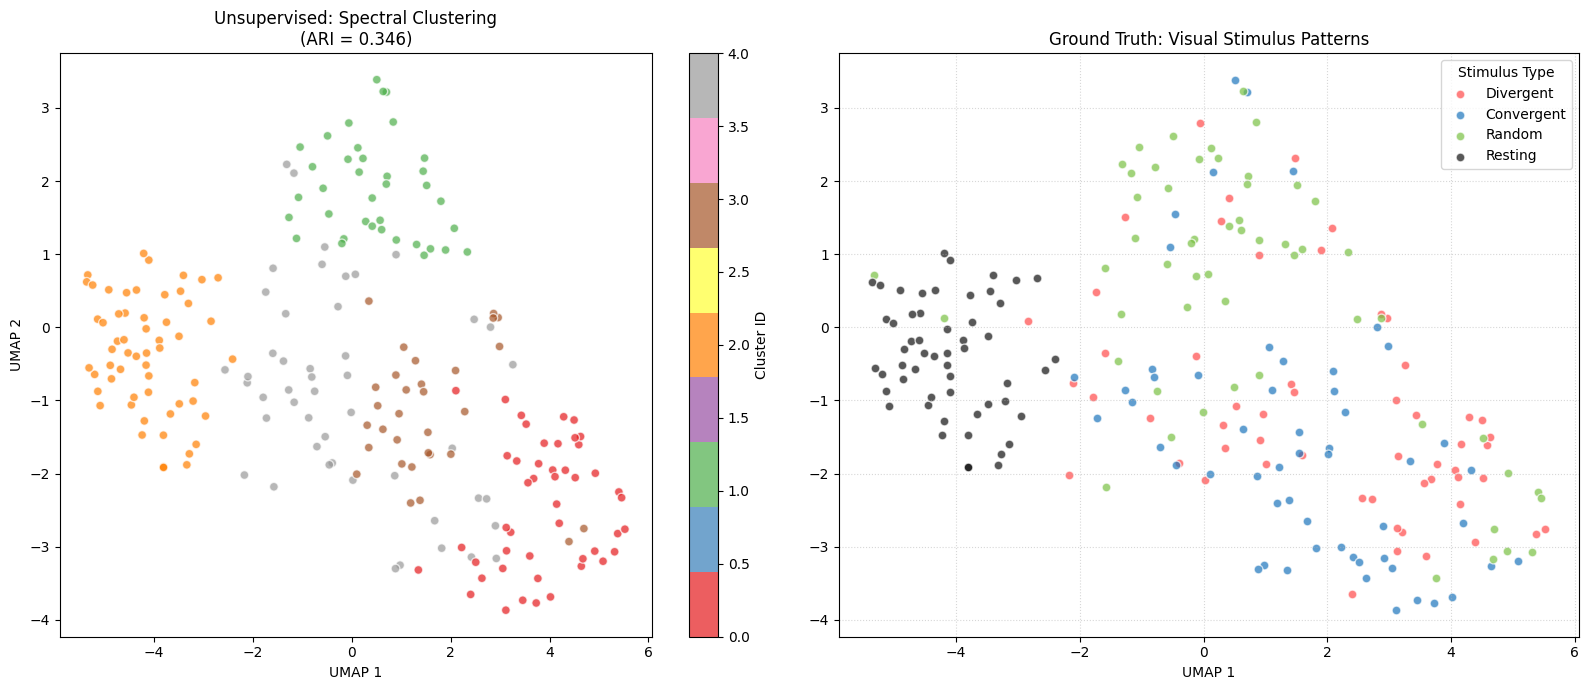

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# 0. 准备标签映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
true_names = [label_names[l] for l in labels_balanced]

# 创建画布：左图展示聚类，右图展示真实标签
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

# --- 左图：谱聚类结果 ---
scatter1 = axes[0].scatter(embedding[:, 0], embedding[:, 1], 
                            c=cluster_labels, cmap='Set1', s=40, alpha=0.7, edgecolors='w')
axes[0].set_title(f"Unsupervised: Spectral Clustering\n(ARI = {adjusted_rand_score(labels_balanced, cluster_labels):.3f})")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
fig.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# --- 右图：实验标签（真实分类） ---
# 使用自定义调色板
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}
for name in ['Divergent', 'Convergent', 'Random', 'Resting']:
    mask = np.array(true_names) == name
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], 
                    label=name, color=colors[name], s=40, alpha=0.7, edgecolors='w')

axes[1].set_title("Ground Truth: Visual Stimulus Patterns")
axes[1].set_xlabel("UMAP 1")
axes[1].legend(title="Stimulus Type")
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

无监督聚类与视觉标签的重合度 (ARI): 0.3456


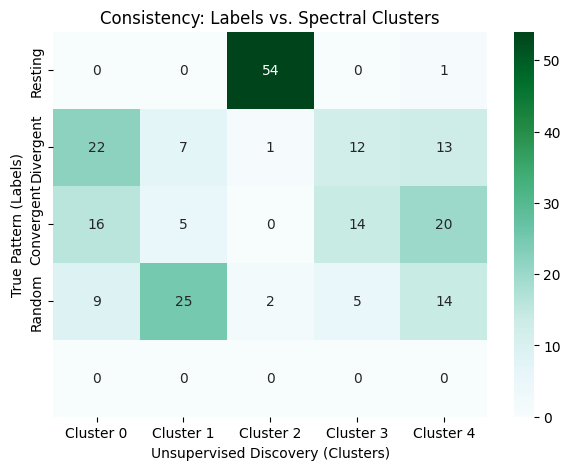

In [10]:
# 1. 计算重合度 (ARI)
ari = adjusted_rand_score(labels_balanced, cluster_labels)
print(f"无监督聚类与视觉标签的重合度 (ARI): {ari:.4f}")

# 2. 绘制混淆矩阵
labels = [i for i in labels_balanced]  # 将标签调整为从0开始

cm = confusion_matrix(labels, cluster_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=[f'Cluster {i}' for i in np.unique(cluster_labels)],
            yticklabels=[label_names[i] for i in np.unique(labels_balanced)])
plt.title("Consistency: Labels vs. Spectral Clusters")
plt.ylabel("True Pattern (Labels)")
plt.xlabel("Unsupervised Discovery (Clusters)")
plt.show()

In [11]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# 1. 构建全局相似性图 (使用余弦相似度)
S = cosine_similarity(X_trial_averaged_balanced)
# 设定阈值（例如相似度前 10% 的连线），将相似度矩阵转为邻接矩阵
threshold = np.percentile(S, 90)
adj = (S > threshold).astype(int)
G_global = nx.from_numpy_array(adj)

# 2. 提取子图并计算特征
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
graph_stats = {}

for val, name in label_names.items():
    # 找到属于该标签的节点索引
    nodes = np.where(labels_balanced == val)[0]
    # 提取诱发子图
    sub_g = G_global.subgraph(nodes)
    
    # 计算特征
    graph_stats[name] = {
        "Density": nx.density(sub_g),
        "Avg_Clustering": nx.average_clustering(sub_g),
        "Transitivity": nx.transitivity(sub_g),
        "Local_Efficiency": nx.local_efficiency(sub_g),
        "Global_Efficiency": nx.global_efficiency(sub_g)
    }

# 3. 打印结果对比
import pandas as pd
print(pd.DataFrame(graph_stats).T)

             Density  Avg_Clustering  Transitivity  Local_Efficiency  \
Divergent   0.247138        0.554581      0.579326          0.777171   
Convergent  0.228956        0.568043      0.507968          0.824799   
Random      0.259933        0.612269      0.639793          0.820726   
Resting     0.037710        0.000000      0.000000          0.036364   

            Global_Efficiency  
Divergent            0.483805  
Convergent           0.507565  
Random               0.488137  
Resting              0.000673  


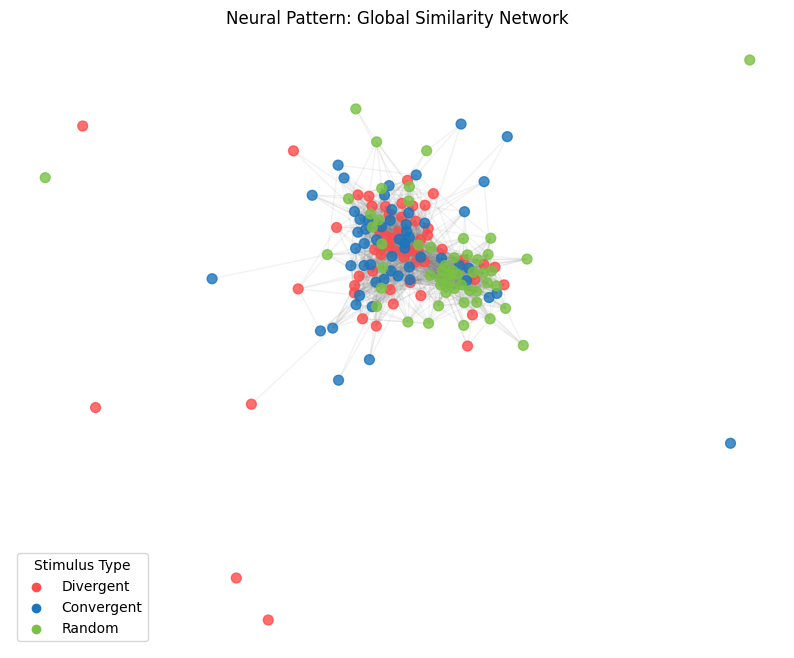

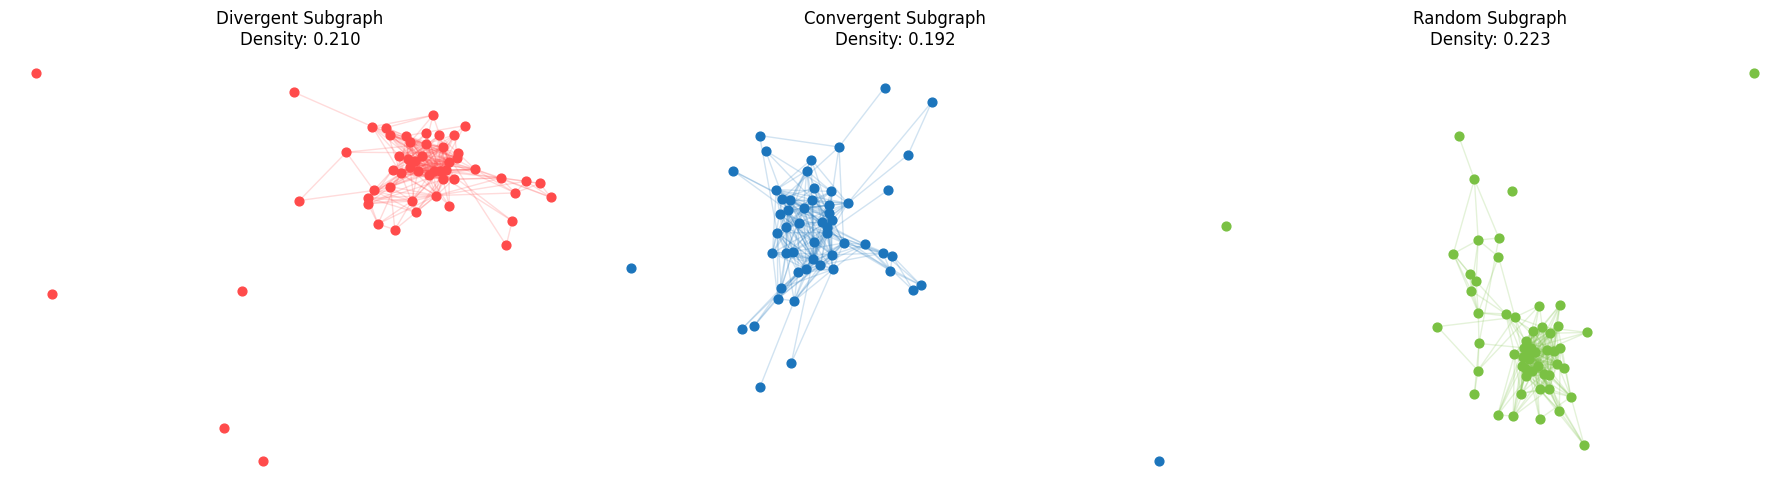

In [12]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def plot_pattern_graphs(X, labels, title_prefix="Neural Pattern"):
    # 1. 计算 Trial 之间的相似度 (余弦相似度)
    S = cosine_similarity(X)
    
    # 2. 设定阈值构建邻接矩阵 (例如保留相似度最高的 10% 的连线)
    threshold = np.percentile(S, 90)
    adj = (S > threshold).astype(int)
    
    node_filter = [i for i, l in enumerate(labels) if l != 0]
    adj = adj[np.ix_(node_filter, node_filter)]
    labels = labels[node_filter]

    # 创建全局图
    G_global = nx.from_numpy_array(adj)
    G_global.remove_edges_from(nx.selfloop_edges(G_global)) # 移除自环
    
    # 定义标签语义和颜色
    label_map = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
    colors_map = {1: '#FF4B4B', 2: '#1C75BC', 3: '#7AC143', 0: '#111111'}
    
    # 设置布局 (力导向布局，让相似的点聚在一起)
    pos = nx.spring_layout(G_global, k=0.2, seed=42)
    
    # --- 绘图 1: 全局连接图 ---
    plt.figure(figsize=(10, 8))
    node_colors = [colors_map.get(l, 'gray') for l in labels]
    
    
    nx.draw_networkx_nodes(G_global, pos, node_size=50, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G_global, pos, alpha=0.1, edge_color='gray')
    
    # 添加图例
    for l, name in label_map.items():
        if name == 'Resting':
            continue
        plt.scatter([], [], c=colors_map[l], label=name)
    plt.legend(title="Stimulus Type")
    plt.title(f"{title_prefix}: Global Similarity Network")
    plt.axis('off')
    plt.show()

    # --- 绘图 2: 三种模式子图对比 ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (l, name) in enumerate(label_map.items()):
        # 提取子图
        if name == 'Resting':
            continue
        nodes = np.where(labels == l)[0]
        sub_g = G_global.subgraph(nodes)
        
        # 子图布局
        sub_pos = {n: pos[n] for n in nodes}
        nx.draw_networkx_nodes(sub_g, sub_pos, ax=axes[i], node_size=40, node_color=colors_map[l])
        nx.draw_networkx_edges(sub_g, sub_pos, ax=axes[i], alpha=0.2, edge_color=colors_map[l])
        
        # 计算该子图的密度
        density = nx.density(sub_g)
        axes[i].set_title(f"{name} Subgraph\nDensity: {density:.3f}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 调用函数 (使用您之前的变量)
plot_pattern_graphs(X_trial_averaged_balanced, labels_balanced)

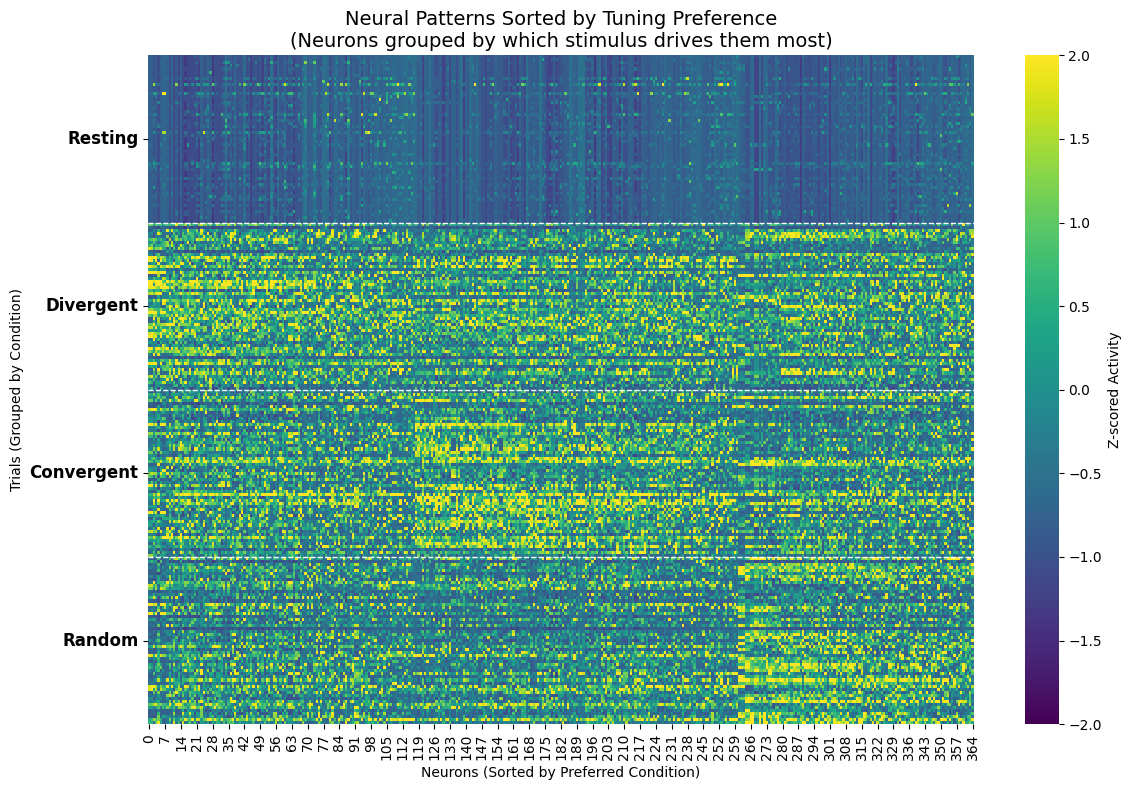

Generating Clustermap (Hierarchical Clustering)...


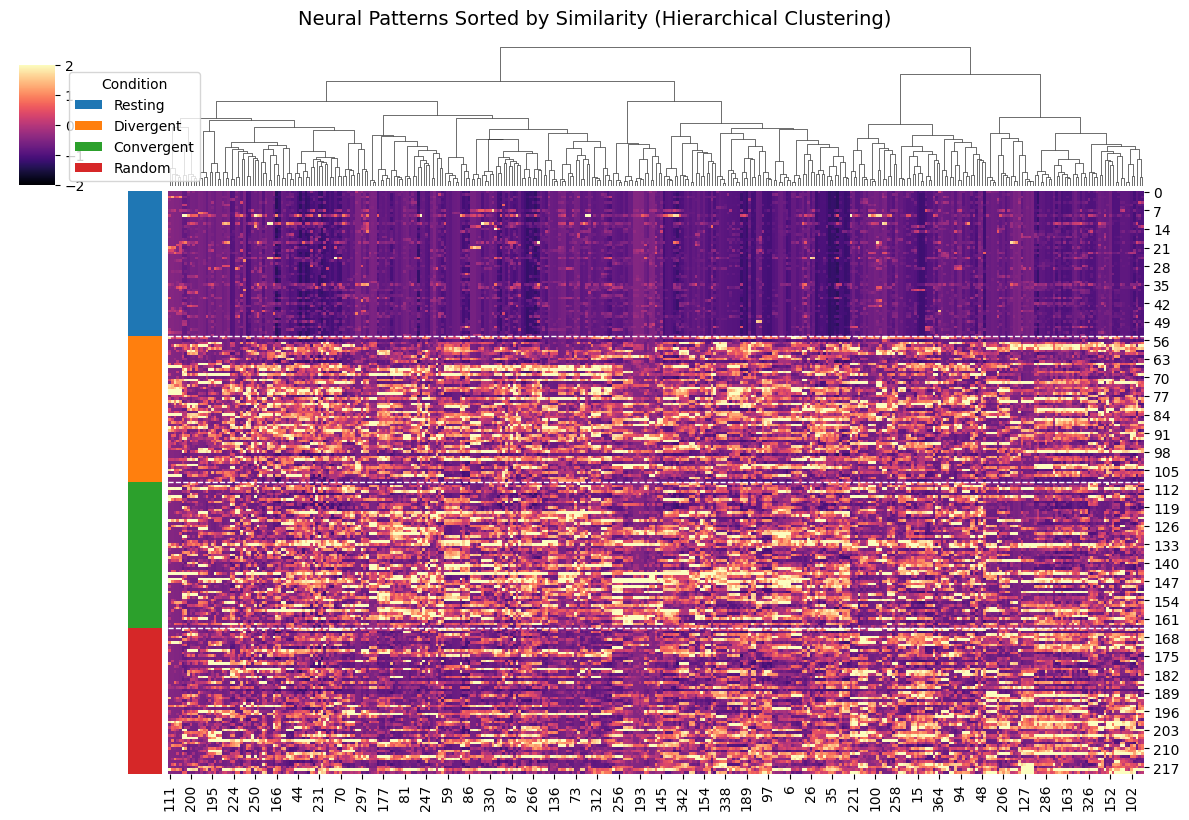

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

def plot_sorted_neural_patterns(X, labels, label_map):
    """
    可视化神经元活动热图，通过两种策略对神经元（X轴）进行排序，
    以揭示不同刺激条件（Y轴）下的Pattern差异。
    """
    
    # 1. 数据预处理
    # ------------------------------------------------
    # Z-score 归一化：消除神经元绝对发放率的差异，只看相对变化
    # axis=0 对每一列（神经元）做归一化
    X_norm = zscore(X, axis=0)
    
    # 替换 NaN (如果有些神经元完全不发放，std为0，zscore会产生nan)
    X_norm = np.nan_to_num(X_norm)
    
    unique_labels = np.unique(labels)
    sorted_labels = sorted(unique_labels) # 确保顺序: Divergent, Convergent, Random...
    
    # 获取标签的分界线位置，用于画横线
    label_counts = [np.sum(labels == l) for l in sorted_labels]
    boundaries = np.cumsum(label_counts)[:-1]
    
    # 重新排列 X 的行（Trial），确保它是按 Label 顺序排列的
    # (虽然通常已经是排好的，但为了保险起见)
    trial_sort_idx = np.argsort(labels)
    X_sorted_trials = X_norm[trial_sort_idx]
    labels_sorted = labels[trial_sort_idx]
    
    # ------------------------------------------------
    # 策略一：偏好性排序 (Preference Sorting)
    # ------------------------------------------------
    # 计算每个神经元在各条件下的平均活动
    n_neurons = X.shape[1]
    neuron_means = np.zeros((len(unique_labels), n_neurons))
    
    for i, l in enumerate(sorted_labels):
        # 找到该条件下的所有行
        mask = (labels == l)
        # 计算该条件下每个神经元的均值
        neuron_means[i, :] = np.mean(X_norm[mask], axis=0)
        
    # 找出每个神经元在哪个条件下最强 (Argmax)
    peak_condition_idx = np.argmax(neuron_means, axis=0)
    
    # 在同一个条件下，再按强度排个序，为了视觉更好看
    peak_magnitude = np.max(neuron_means, axis=0)
    
    # 综合排序键值: 先按条件ID排，再按强度排
    # 技巧: use lexsort. Primary key is last argument.
    sort_key = np.lexsort((-peak_magnitude, peak_condition_idx))
    
    X_pref_sorted = X_sorted_trials[:, sort_key]
    
    # ------------------------------------------------
    # 绘图 1: 偏好性排序热图
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(X_pref_sorted, ax=ax, cmap='viridis', vmin=-2, vmax=2, cbar_kws={'label': 'Z-scored Activity'})
    
    # 画水平线分隔不同条件
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    # 标注 Y 轴
    # 计算每个 Block 的中心位置
    y_centers = []
    current = 0
    for count in label_counts:
        y_centers.append(current + count/2)
        current += count
        
    ax.set_yticks(y_centers)
    ax.set_yticklabels([label_map[l] for l in sorted_labels], rotation=0, fontsize=12, fontweight='bold')
    
    ax.set_title("Neural Patterns Sorted by Tuning Preference\n(Neurons grouped by which stimulus drives them most)", fontsize=14)
    ax.set_xlabel("Neurons (Sorted by Preferred Condition)")
    ax.set_ylabel("Trials (Grouped by Condition)")
    
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------
    # 策略二：层次聚类 (Hierarchical Clustering)
    # ------------------------------------------------
    # 这会展示神经元的自然功能团
    print("Generating Clustermap (Hierarchical Clustering)...")
    
    # 创建行颜色条
    label_colors = {l: sns.color_palette("tab10")[i] for i, l in enumerate(unique_labels)}
    row_colors = [label_colors[l] for l in labels_sorted]
    
    g = sns.clustermap(X_sorted_trials, 
                       method='ward', # 聚类算法
                       metric='euclidean',
                       col_cluster=True, # 对神经元聚类
                       row_cluster=False, # 不对 Trial 聚类 (保持条件顺序)
                       row_colors=row_colors,
                       cmap='magma', vmin=-2, vmax=2,
                       figsize=(12, 8),
                       dendrogram_ratio=(0.1, 0.2),
                       cbar_pos=(0.02, 0.8, 0.03, 0.15))
    
    # 添加水平线
    for b in boundaries:
        g.ax_heatmap.hlines(b, *g.ax_heatmap.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    g.fig.suptitle("Neural Patterns Sorted by Similarity (Hierarchical Clustering)", y=1.02, fontsize=14)
    
    # 手动添加 Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=label_colors[l], label=label_map[l]) for l in sorted_labels]
    plt.legend(handles=handles, title='Condition', bbox_to_anchor=(1.2, 1), loc='upper left')
    
    plt.show()

# 运行代码
# 确保 X_trial_averaged_balanced 是 (n_trials, n_neurons)
plot_sorted_neural_patterns(X_trial_averaged_balanced, labels_balanced, label_names)

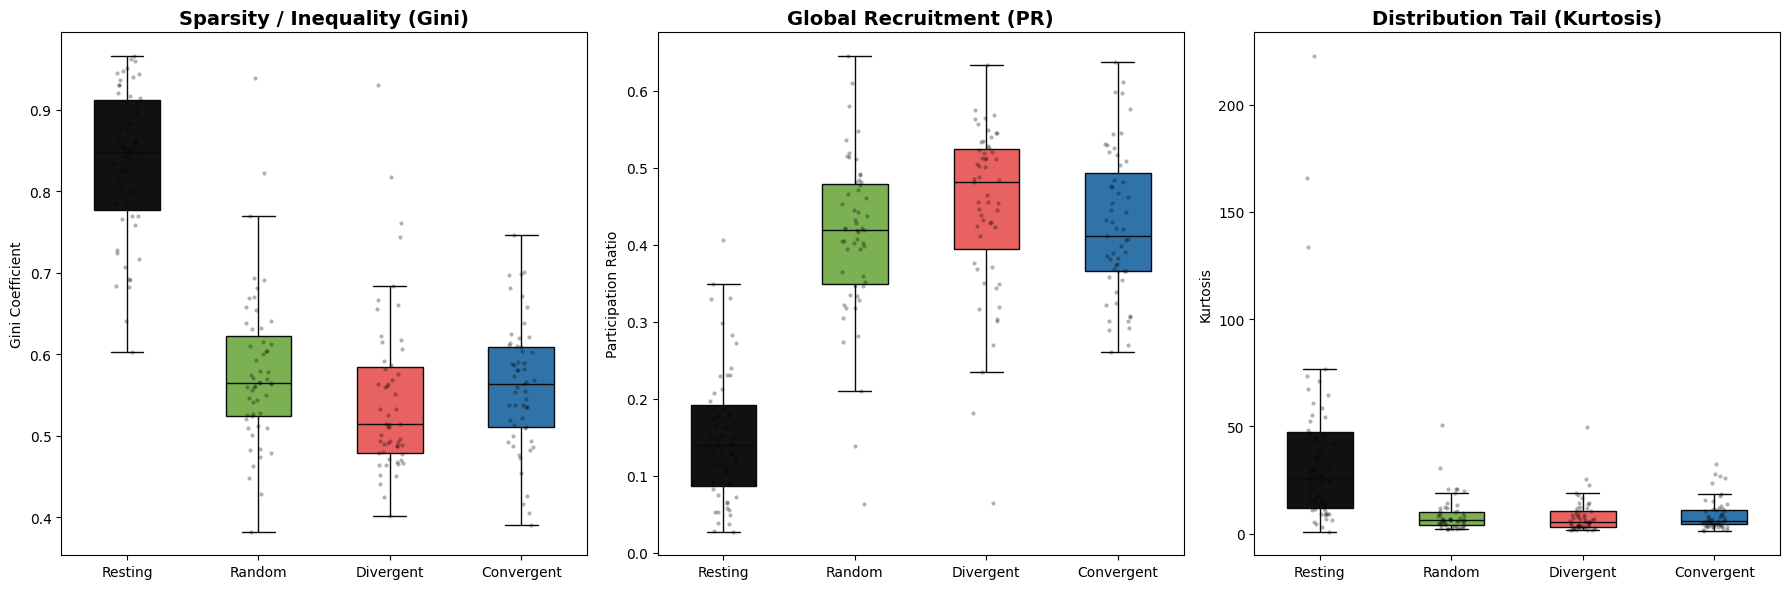

=== Statistical Quantification of Recruitment ===

Metric: Gini Coefficient
  Random Mean: 0.5798 | Coherent Mean: 0.5536
  Wilcoxon Rank-Sum Test: Statistic=1.90, P-value=5.7733e-02

Metric: Participation Ratio
  Random Mean: 0.4119 | Coherent Mean: 0.4375
  Wilcoxon Rank-Sum Test: Statistic=-1.60, P-value=1.1027e-01

Metric: Kurtosis
  Random Mean: 8.7989 | Coherent Mean: 8.4246
  Wilcoxon Rank-Sum Test: Statistic=0.52, P-value=6.0170e-01


In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, ranksums

# -----------------------------------------------------------
# 1. 定义计算函数
# -----------------------------------------------------------

def calculate_gini(array):
    """
    计算基尼系数 (Gini Coefficient)
    0 = 完全平等 (所有神经元发放一致 -> Global Recruitment)
    1 = 完全不平等 (只有一个神经元发放 -> Winner-Take-All)
    """
    # 确保数组为非负 (发放率/dF/F 应该非负，如果是z-score需要先平移或取绝对值，这里假设是dF/F)
    array = np.abs(array) 
    # 加上微小值防止除零
    array = array + 1e-9
    
    sorted_array = np.sort(array)
    n = array.size
    index = np.arange(1, n + 1)
    return ((2 * index - n - 1) * sorted_array).sum() / (n * sorted_array.sum())

def calculate_participation_ratio(array):
    """
    计算参与率 (Participation Ratio)
    反映有效参与编码的神经元数量/比例
    """
    array = np.abs(array)
    numerator = np.sum(array) ** 2
    denominator = np.sum(array ** 2) + 1e-9
    pr = numerator / denominator
    return pr / array.size # 归一化到 0-1 之间

def calculate_population_kurtosis(array):
    """
    计算峰度 (Kurtosis)
    高峰度 = 稀疏 (长尾分布)
    低峰度 = 弥散 (正态或平坦分布)
    """
    return kurtosis(array, fisher=True) # Fisher's definition (normal = 0)

# -----------------------------------------------------------
# 2. 遍历数据进行计算
# -----------------------------------------------------------

# 使用您代码中的变量: X_trial_averaged_balanced (n_trials, n_neurons)
# 和 labels_balanced

metrics_data = []

# 定义标签映射 (保持和您之前的一致)
label_map = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}
colors_map = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}

for i in range(X_trial_averaged_balanced.shape[0]):
    # 提取当前 Trial 的神经元群体向量 (Population Vector)
    pop_vec = X_trial_averaged_balanced[i, :]
    label_idx = labels_balanced[i]
    condition_name = label_map[label_idx]
    
    # 排除 Resting (如果不想分析 Resting 可以取消注释下面这行)
    # if condition_name == 'Resting': continue
    
    # 计算指标
    gini_val = calculate_gini(pop_vec)
    pr_val = calculate_participation_ratio(pop_vec)
    kurt_val = calculate_population_kurtosis(pop_vec)
    
    metrics_data.append({
        'Condition': condition_name,
        'Gini Coefficient': gini_val,
        'Participation Ratio': pr_val,
        'Kurtosis': kurt_val
    })

# 转换为 DataFrame 方便绘图
df_metrics = pd.DataFrame(metrics_data)

# -----------------------------------------------------------
# 3. 绘图与可视化 (Boxplots)
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_style("whitegrid")

# 指标列表
metrics_list = ['Gini Coefficient', 'Participation Ratio', 'Kurtosis']
titles = ['Sparsity / Inequality (Gini)', 'Global Recruitment (PR)', 'Distribution Tail (Kurtosis)']

# 指定绘图顺序
order = ['Resting', 'Random', 'Divergent', 'Convergent']

for i, metric in enumerate(metrics_list):
    sns.boxplot(x='Condition', y=metric, data=df_metrics, 
                order=order, palette=colors_map, ax=axes[i], 
                width=0.5, showfliers=False) # showfliers=False 去除异常值让图更干净
    
    # 加上抖动点 (Stripplot) 展示原始数据分布
    sns.stripplot(x='Condition', y=metric, data=df_metrics, 
                  order=order, color='black', alpha=0.3, size=3, ax=axes[i])
    
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 4. 统计检验 (Statistical Test)
# -----------------------------------------------------------

print("=== Statistical Quantification of Recruitment ===")

# 定义要比较的组: Random vs Coherent (Divergent + Convergent)
random_vals = df_metrics[df_metrics['Condition'] == 'Random']
coherent_vals = df_metrics[df_metrics['Condition'].isin(['Divergent', 'Convergent'])]

for metric in metrics_list:
    stat, p_val = ranksums(random_vals[metric], coherent_vals[metric])
    
    # 计算均值便于描述
    mean_rand = random_vals[metric].mean()
    mean_coh = coherent_vals[metric].mean()
    
    print(f"\nMetric: {metric}")
    print(f"  Random Mean: {mean_rand:.4f} | Coherent Mean: {mean_coh:.4f}")
    print(f"  Wilcoxon Rank-Sum Test: Statistic={stat:.2f}, P-value={p_val:.4e}")
    
    if p_val < 0.05:
        if metric == 'Gini Coefficient' or metric == 'Kurtosis':
            if mean_rand > mean_coh:
                print(f"  -> VALIDATED: Random is significantly more SPARSE than Coherent.")
        elif metric == 'Participation Ratio':
            if mean_coh > mean_rand:
                print(f"  -> VALIDATED: Coherent shows significantly higher RECRUITMENT than Random.")

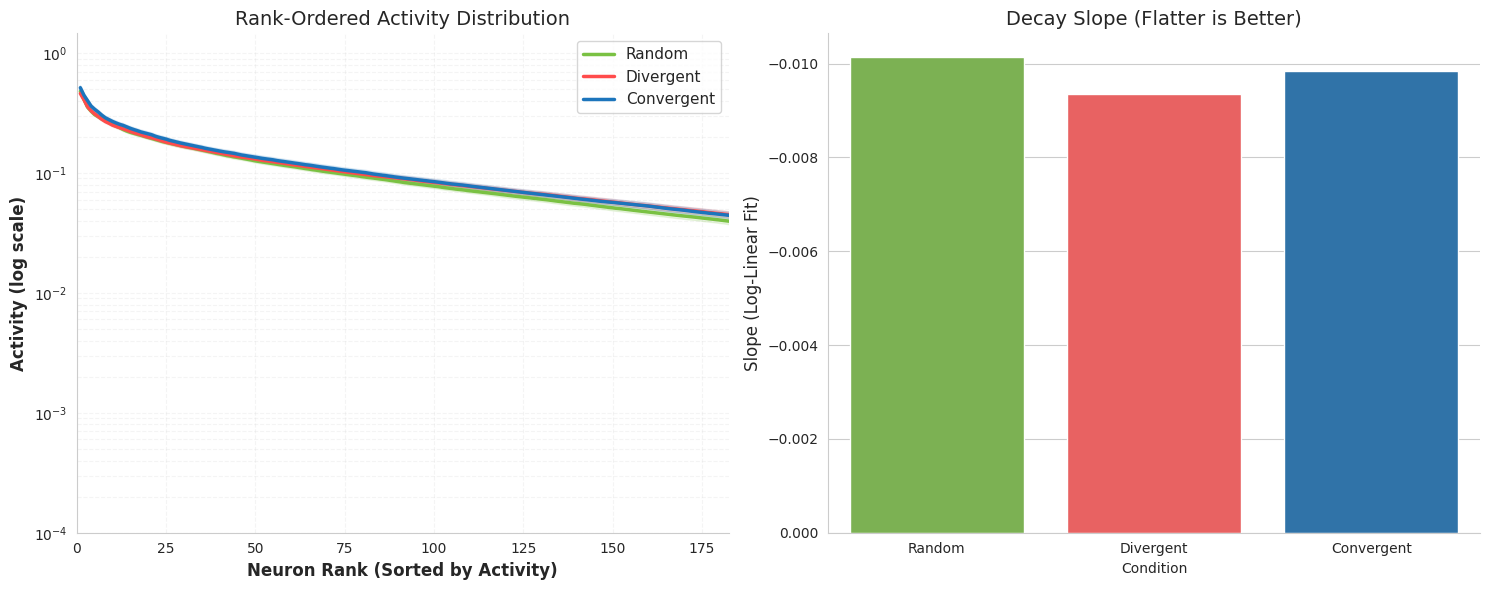

=== Slope Quantification (Slower decay = More Global Recruitment) ===
    Condition  Decay Slope        R2
0      Random    -0.010140  0.972360
1   Divergent    -0.009359  0.967419
2  Convergent    -0.009836  0.967545


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# -----------------------------------------------------------
# 1. 定义绘图与分析函数
# -----------------------------------------------------------

def plot_rank_ordered_activity(X, y, label_map, colors_map, ax=None):
    """
    绘制排序后的神经元活动分布 (Rank-Activity Plot)
    并计算中间段的衰减斜率 (Decay Slope)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        
    slope_results = []
    
    # 遍历每个条件
    # 建议顺序：Random -> Divergent -> Convergent (Resting 可选)
    plot_order = [3, 1, 2] # 对应 label_map 的 key
    
    for label_idx in plot_order:
        condition_name = label_map.get(label_idx)
        if condition_name is None: continue
        
        # 1. 提取该条件下的所有 Trial 数据
        indices = np.where(y == label_idx)[0]
        if len(indices) == 0: continue
        X_cond = X[indices, :] # (n_trials, n_neurons)
        
        # 2. 关键步骤：对每一行(Trial)独立进行从大到小排序
        # 这样我们比较的是“分布的形状”，而不是“哪一个神经元”
        # np.abs 确保 dF/F 噪音造成的微小负值不影响 Log 计算
        X_sorted = np.sort(np.abs(X_cond), axis=1)[:, ::-1]
        
        # 3. 计算平均曲线和标准误 (SEM)
        mean_curve = np.mean(X_sorted, axis=0)
        sem_curve = np.std(X_sorted, axis=0) / np.sqrt(X_sorted.shape[0])
        
        # 4. 准备 X 轴 (Rank)
        ranks = np.arange(1, len(mean_curve) + 1)
        
        # 5. 处理 Log 0 问题 (加极小值)
        mean_curve_log = mean_curve + 1e-9
        
        # 6. 绘图 (Semilog-y: Y轴取对数，X轴线性)
        # 这样指数衰减会变成一条直线，斜率直接反映稀疏度
        ax.plot(ranks, mean_curve_log, label=condition_name, 
                color=colors_map[condition_name], linewidth=2.5)
        
        ax.fill_between(ranks, 
                        mean_curve_log - sem_curve, 
                        mean_curve_log + sem_curve, 
                        color=colors_map[condition_name], alpha=0.15)
        
        # 7. 计算斜率 (Decay Slope)
        # 只拟合中间段 (比如前 1% 到 50%)，避开头部极值和尾部噪音
        n_neurons = len(mean_curve)
        start_idx = int(n_neurons * 0.01)  # 跳过前 1% (Winner)
        end_idx = int(n_neurons * 0.50)    # 截止到 50% (Body)
        
        if end_idx > start_idx:
            # 在 Log 空间做线性回归 -> 得到指数衰减率
            slope, intercept, r_val, _, _ = linregress(ranks[start_idx:end_idx], 
                                                       np.log(mean_curve_log[start_idx:end_idx]))
            
            slope_results.append({
                'Condition': condition_name,
                'Decay Slope': slope, # 绝对值越大越陡峭 (Sparse)
                'R2': r_val**2
            })

    # 美化图表
    ax.set_yscale('log') # 关键！使用对数坐标
    ax.set_xlabel('Neuron Rank (Sorted by Activity)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Activity (log scale)', fontsize=12, fontweight='bold')
    ax.set_title('Rank-Ordered Activity Distribution', fontsize=14)
    ax.legend(fontsize=11)
    
    # 限制 X 轴范围，聚焦前 50% 或前 1000 个神经元，否则尾巴太长看不清
    ax.set_xlim(0, X.shape[1] * 0.5) 
    ax.set_ylim(bottom=1e-4) # 根据你的数据范围调整下限
    
    sns.despine()
    ax.grid(True, which="both", ls="--", alpha=0.2)
    
    return pd.DataFrame(slope_results)

# -----------------------------------------------------------
# 2. 执行绘图
# -----------------------------------------------------------

# 假设 label_map 和 colors_map 已经定义
# label_map = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 图1: 曲线图
df_slopes = plot_rank_ordered_activity(X_trial_averaged_balanced, labels_balanced, 
                                       label_map, colors_map, ax=ax1)

# 图2: 斜率量化对比 (Barplot)
sns.barplot(x='Condition', y='Decay Slope', data=df_slopes, 
            palette=colors_map, ax=ax2, order=['Random', 'Divergent', 'Convergent'])

ax2.set_title('Decay Slope (Flatter is Better)', fontsize=14)
ax2.set_ylabel('Slope (Log-Linear Fit)', fontsize=12)
ax2.invert_yaxis() # 翻转Y轴，因为斜率是负的，越长(越负)代表越陡峭

plt.tight_layout()
plt.show()

print("=== Slope Quantification (Slower decay = More Global Recruitment) ===")
print(df_slopes[['Condition', 'Decay Slope', 'R2']])